<div style="background: linear-gradient(120deg, #102a43 0%, #176b87 52%, #2a9d8f 100%); padding: 28px 36px; border-radius: 14px; display: flex; align-items: center; gap: 28px; box-shadow: 0 5px 20px rgba(16,42,67,0.28);">
    <img src='Figures/iteso.png' style="height: 110px; border-radius: 8px; background: white; padding: 6px; flex-shrink: 0; box-shadow: 0 2px 8px rgba(0,0,0,0.22);"/>
    <div style="border-left: 2px solid rgba(255,255,255,0.45); padding-left: 28px;">
        <h1 style="margin: 0 0 8px 0; color: white; font-size: 1.5em; line-height: 1.3; letter-spacing: 0.01em;">Examen Primer Parcial Versión C</h1>
        <h3 style="margin: 0 0 8px 0; color: rgba(255,255,255,0.86); font-weight: normal; font-size: 1.05em;">Laboratorio de Procesamiento de Datos</h3>
        <div style="color: rgba(255,255,255,0.78); font-size: 0.95em;">Fecha: 01/10/2026</div>
    </div>
</div>


<div style="border-left: 4px solid #176b87; padding: 14px 18px; margin: 8px 0 18px 0;">
    <strong style="color: #102a43;">Nombre del alumno:SANTIAGO NUÑEZ PEREZ</strong>
    <span> </span>
</div>



### Instrucciones
1. Resuelve los **3 ejercicios** en este notebook. Agrega las celdas de código y de texto que necesites.
2. Todos los archivos están en la carpeta `datos/` junto a este notebook. Usa las variables `DATOS` y `SALIDA` que son generadas en la primera celda de código abajo.
3. **Nota:** El notebook debe ejecutarse completo con *Restart & Run All* sin errores.


In [1]:
# Configuración (no modificar)
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

DATOS = "datos"
SALIDA = "salidas"
os.makedirs(SALIDA, exist_ok=True)
print("Archivos disponibles:", sorted(os.listdir(DATOS)))

Archivos disponibles: ['adult.data', 'co2_owid.csv', 'ejercicio_particionado', 'gasto_salud_ocde.xlsx', 'grace_hopper.jpg']


---
## Ejercicio 1: Extracción multi‑fuente (30 pts)

**Parte A: Excel con una hoja por país (`gasto_salud_ocde.xlsx`)**

Cada hoja contiene `Year`, `Spending_USD` (gasto en salud per cápita) y `Life_Expectancy` de un país.

1. (5 pts) Lee **todas** las hojas en una sola instrucción (`sheet_name=None`). Muestra el nombre de cada hoja y su `shape`.
2. (5 pts) Une todas las hojas en un solo `DataFrame` con una columna `pais` que salga del **nombre de la hoja**. Muestra, para cada país, el último año Zisponible con su gasto y esperanza de vida.
3. (5 pts) Con `pd.ExcelWriter` genera `salidas/resumen_salud.xlsx` con dos hojas: `Ultimo_anio` (resultado anterior) y `Promedios` (promedio de gasto y esperanza de vida por país).


**Parte B: Imagen: `grace_hopper.jpg`**

4. (5 pts) Abre la imagen con `PIL`, conviértela a arreglo `numpy` y reporta `shape`, `dtype`, valores mínimo/máximo y la **media por canal** (R, G, B).
5. (5 pts) Convierte la imagen a escala de grises, muestra ambas versiones en un gráfico (imagen a color vs escala de grisis) y guarda la imagen en escala de gris como `salidas/grace_hopper_gris.png`. ¿Qué tipo de variable (discreta/continua) es la intensidad de un píxel?
6. (5 pts) Aplica un filtro Gaussiano a la imagen en escala de grises. Construye tu propio kernel gaussiano 2D con NumPy a partir de la fórmula:
$$ G(x, y) = \frac{1}{2\pi\sigma^2} e^{-\frac{x^2+y^2}{2\sigma^2}} $$
usando `np.meshgrid` para generar las coordenadas $x, y$ alrededor del centro del kernel y guarda la imagen en `salidas/grace_hopper_gris_filtro.png`.


In [2]:
# Ejercicio 1 - Parte A
# 1. Leer todas las hojas en un diccionario en una sola instrucción
ruta_excel = os.path.join(DATOS, "gasto_salud_ocde.xlsx")
hojas_salud = pd.read_excel(ruta_excel, sheet_name=None)

print("Hojas leídas y sus dimensiones:")
for nombre_hoja, df_hoja in hojas_salud.items():
    print(f" - Hoja: {nombre_hoja:<15} | Shape: {df_hoja.shape}")

Hojas leídas y sus dimensiones:
 - Hoja: Canada          | Shape: (44, 3)
 - Hoja: France          | Shape: (35, 3)
 - Hoja: Germany         | Shape: (50, 3)
 - Hoja: Great Britain   | Shape: (43, 3)
 - Hoja: Japan           | Shape: (51, 3)
 - Hoja: USA             | Shape: (51, 3)


In [ ]:
# 2. Unir todas las hojas en un solo DataFrame agregando la columna 'pais'
lista_dfs = []
for pais, df in hojas_salud.items():
    df_temp = df.copy()
    df_temp["pais"] = pais
    lista_dfs.append(df_temp)

df_salud = pd.concat(lista_dfs, ignore_index=True)

# Obtener para cada país el último año disponible 
idx_ultimo = df_salud.groupby("pais")["Year"].idxmax()
df_ultimo_anio = df_salud.loc[idx_ultimo, ["pais", "Year", "Spending_USD", "Life_Expectancy"]].sort_values("pais").reset_index(drop=True)

print("Último año disponible por país:")
print(df_ultimo_anio)

Último año disponible por país:
            pais  Year  Spending_USD  Life_Expectancy
0         Canada  2020      5828.324             81.7
1         France  2020      5468.418             82.3
2        Germany  2020      6938.983             81.1
3  Great Britain  2020      5018.700             80.4
4          Japan  2020      4665.641             84.7
5            USA  2020     11859.179             77.0


In [4]:
# 3. Calcular promedios de gasto y esperanza de vida por país
df_promedios = (
    df_salud.groupby("pais", as_index=False)[["Spending_USD", "Life_Expectancy"]]
    .mean()
    .rename(columns={
        "Spending_USD": "Promedio_Spending_USD",
        "Life_Expectancy": "Promedio_Life_Expectancy"
    })
)

# Guardar en 'salidas/resumen_salud.xlsx' con pd.ExcelWriter
ruta_resumen = os.path.join(SALIDA, "resumen_salud.xlsx")
with pd.ExcelWriter(ruta_resumen) as writer:
    df_ultimo_anio.to_excel(writer, sheet_name="Ultimo_anio", index=False)
    df_promedios.to_excel(writer, sheet_name="Promedios", index=False)

print(f"Archivo generado en: {ruta_resumen}")

Archivo generado en: salidas\resumen_salud.xlsx


In [5]:
# Ejercicio 1 - Parte B

# 4. Abrir con PIL y convertir a NumPy array
ruta_imagen = os.path.join(DATOS, "grace_hopper.jpg")
img_pil = Image.open(ruta_imagen)
img_np = np.array(img_pil)

# Reporte de propiedades y estadísticas
print("Propiedades de la imagen")
print(f"Shape:         {img_np.shape}")
print(f"Dtype:         {img_np.dtype}")
print(f"Valor Mínimo:  {img_np.min()}")
print(f"Valor Máximo:  {img_np.max()}")

# Media por canal (R, G, B)
media_r = img_np[:, :, 0].mean()
media_g = img_np[:, :, 1].mean()
media_b = img_np[:, :, 2].mean()

print(f"\nMedia Canal Rojo (R):  {media_r:.2f}")
print(f"Media Canal Verde (G): {media_g:.2f}")
print(f"Media Canal Azul (B):  {media_b:.2f}")

Propiedades de la imagen
Shape:         (600, 512, 3)
Dtype:         uint8
Valor Mínimo:  0
Valor Máximo:  255

Media Canal Rojo (R):  82.48
Media Canal Verde (G): 72.43
Media Canal Azul (B):  86.42


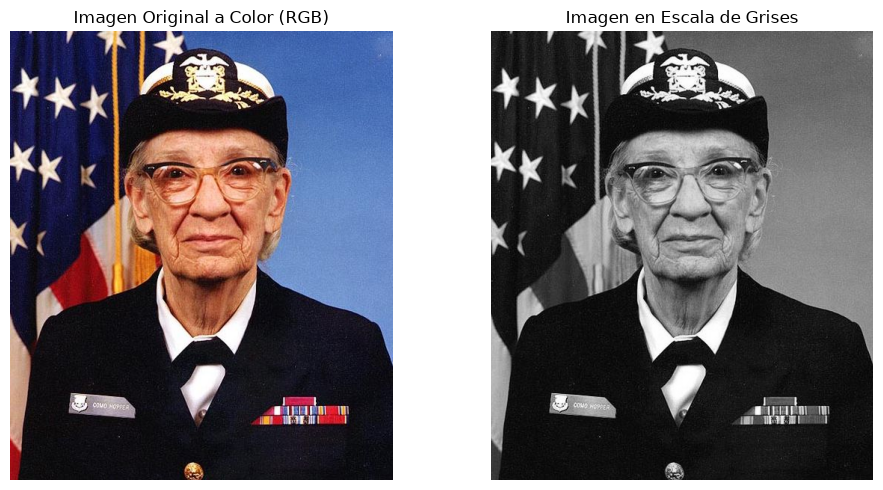

Imagen en gris guardada en: salidas\grace_hopper_gris.png


In [6]:
# 5. Convertir a escala de grises y guardar
img_gris_pil = img_pil.convert("L")
img_gris_np = np.array(img_gris_pil)

ruta_gris_png = os.path.join(SALIDA, "grace_hopper_gris.png")
img_gris_pil.save(ruta_gris_png)

# Mostrar ambas versiones en un gráfico comparativo
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(img_np)
axes[0].set_title("Imagen Original a Color (RGB)")
axes[0].axis("off")

axes[1].imshow(img_gris_np, cmap="gray")
axes[1].set_title("Imagen en Escala de Grises")
axes[1].axis("off")

plt.tight_layout()
plt.show()
print(f"Imagen en gris guardada en: {ruta_gris_png}")


## ¿Qué tipo de variable (discreta/continua) es la intensidad de un píxel?

Se considera una variable discreta ya que a nivel de color computacionalmente se representa con numeros enteros y contables del 0 al 255 en una imagen de 8 bits 

Kernel Gaussiano normalizado (5x5):
 [[0.003  0.0133 0.0219 0.0133 0.003 ]
 [0.0133 0.0596 0.0983 0.0596 0.0133]
 [0.0219 0.0983 0.1621 0.0983 0.0219]
 [0.0133 0.0596 0.0983 0.0596 0.0133]
 [0.003  0.0133 0.0219 0.0133 0.003 ]]


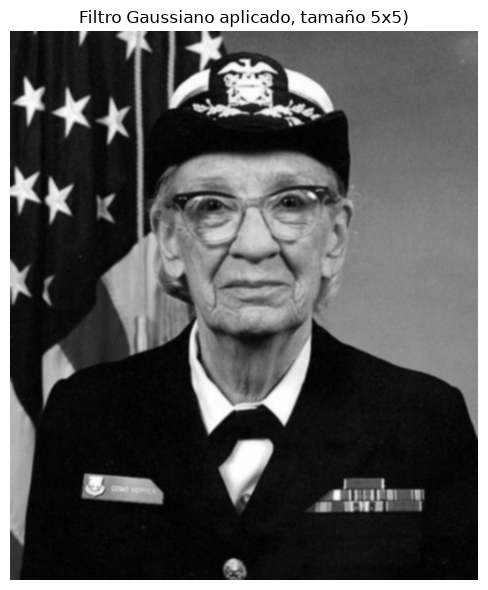

Imagen filtrada guardada en: salidas\grace_hopper_gris_filtro.png


In [7]:
# 6. Construcción del kernel gaussiano 2D
k_size = 5          # Tamaño de la ventana (5x5)
sigma = 1.0         # Desviación estándar
r = k_size // 2     # Radio alrededor del centro

# Generación de la cuadrícula de coordenadas con np.meshgrid
x = np.arange(-r, r + 1)
y = np.arange(-r, r + 1)
X, Y = np.meshgrid(x, y)

# Fórmula matemática dada: G(x, y) = (1 / (2 * pi * sigma^2)) * exp(-(x^2 + y^2) / (2 * sigma^2))
kernel_gaussiano = (1 / (2 * np.pi * (sigma**2))) * np.exp(-(X**2 + Y**2) / (2 * (sigma**2)))

# Normalización para que la suma sea 1
kernel_gaussiano = kernel_gaussiano / np.sum(kernel_gaussiano)

print("Kernel Gaussiano normalizado (5x5):\n", np.round(kernel_gaussiano, 4))

# Convolución 2D vectorizada
H, W = img_gris_np.shape
img_padded = np.pad(img_gris_np, pad_width=r, mode="reflect").astype(np.float64)
img_filtrada = np.zeros((H, W), dtype=np.float64)

for i in range(k_size):
    for j in range(k_size):
        img_filtrada += kernel_gaussiano[i, j] * img_padded[i : i + H, j : j + W]

# Ajustar rango [0, 255] y convertir a uint8
img_filtrada = np.clip(img_filtrada, 0, 255).astype(np.uint8)

# Guardar imagen resultante
ruta_filtro_png = os.path.join(SALIDA, "grace_hopper_gris_filtro.png")
Image.fromarray(img_filtrada).save(ruta_filtro_png)

# Mostrar el resultado del filtro
fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(img_filtrada, cmap="gray")
ax.set_title(f"Filtro Gaussiano aplicado, tamaño {k_size}x{k_size})")
ax.axis("off")
plt.tight_layout()
plt.show()

print(f"Imagen filtrada guardada en: {ruta_filtro_png}")   

---
## Ejercicio 2: Clasificación de tipos de datos (40 pts)

El archivo `adult.data` proviene del censo de EE. UU. de 1994. **No tiene encabezado**, los campos están separados por `", "` y los valores desconocidos se capturaron como `"?"`. Usa la lista `columnas` de la celda siguiente para nombrar a las variables (columnas del dataframe).

1. (10 pts) Carga el archivo con pd.read_csv() con los argumentos de entrada: `names=columnas`, `skipinitialspace=True` y `na_values="?"`. Muestra `shape`, `dtypes` y `nunique()`. ¿Qué pasaría con los `"?"` si no usas `na_values` como argumento de entrada en pd.read_csv()?
2. (10 pts) Clasifica en una tabla Markdown: `age`, `workclass`, `fnlwgt`, `education`, `education_num`, `marital_status`, `occupation`, `sex`, `capital_gain`, `hours_per_week`, `native_country`, `income`.

   | Variable | Cualitativa / Cuantitativa | Subtipo | Justificación |
   |---|---|---|---|

3. (5 pts) Crea `income_alto` (1 si `>50K`, 0 si no). Calcula la proporción de ingreso alto (`income_alto` ) por nivel de `education`  y por `sex` (puedes agrupar por `education` y aplicar la media para `income_alto`, lo mismo para la columna `sex` ). Muestra una gráfica la primera (proporción de ingreso alto (`income_alto` ) por nivel de `education`).
4. (5 pts) Analiza la columna `capital_gain`: cuántos registros tienen exactamente `99999`. ¿Qué crees que significa ese valor? 
5. (10 pts) Escribe una función `reporte_calidad_datos(df)` que devuelva por columna: `dtype`, `n_unicos`, `%_faltantes`, `tipo_sugerido`. Obten un reporte de calidad de datos del archivo original, ¿qué columnas tienen faltantes y en qué %? 

In [8]:
columnas = ["age", "workclass", "fnlwgt", "education", "education_num", "marital_status",
            "occupation", "relationship", "race", "sex", "capital_gain", "capital_loss",
            "hours_per_week", "native_country", "income"]

In [9]:
# Ejercicio 2

# 1. Cargar el archivo con argumentos especificados
ruta_adult = os.path.join(DATOS, "adult.data")
df_adult = pd.read_csv(
    ruta_adult,
    names=columnas,
    skipinitialspace=True,
    na_values="?"
)

# Mostrar dimensiones, tipos de datos y valores únicos por columna
print(f"Dimensiones (shape): {df_adult.shape}\n")

print("--- Tipos de datos (dtypes) ---")
print(df_adult.dtypes)

print("\n--- Valores únicos por columna (nunique) ---")
print(df_adult.nunique())

Dimensiones (shape): (32561, 15)

--- Tipos de datos (dtypes) ---
age               int64
workclass           str
fnlwgt            int64
education           str
education_num     int64
marital_status      str
occupation          str
relationship        str
race                str
sex                 str
capital_gain      int64
capital_loss      int64
hours_per_week    int64
native_country      str
income              str
dtype: object

--- Valores únicos por columna (nunique) ---
age                  73
workclass             8
fnlwgt            21648
education            16
education_num        16
marital_status        7
occupation           14
relationship          6
race                  5
sex                   2
capital_gain        119
capital_loss         92
hours_per_week       94
native_country       41
income                2
dtype: int64


**Tabla de clasificación y respuestas del Ejercicio 2:**

| Variable | Cualitativa / Cuantitativa | Subtipo  | Justificación |
|---|---|---|---|
| age | Cuantitativa | Discreta (registrada en años enteros; conceptualmente continua) | Edad en años cumplidos |
| workclass | Cualitativa | Nominal | Sector o tipo de empleo sin orden o jerarquia | 
| fnlwgt | Cuantitativa | Continua | Peso final muestral calculado  |
| education | Cualitativa | Ordinal | Nivel educativo maximo alcanzado con jerarquia y orden |
| education_num | Cuantitativa | Discreta | Representa el numero de años o nivel de escolaridad |
| marital_status | Cualitativa | Nominal | Estado civil del individuo, categorias sin relacion de orden |
| Occupation | Cualitativa | Nominal | Area o rol de trabajo, sin jerarquia |
| Sex | Cualitativa | Binaria | Variable categorica con dos valores unicamente |
| capital_gain | Cuantitativa | Continua | Ganancia financiera de capital en dolares |
| hours_per_week | Cuantitativa | Continua | Cantidad de horas laborales dedicadas por semana |
| native_country | Cualitativa | Nominal | Pais de procedencia sin orden numerico o jerarquico |
| income | Cualitativa | Binaria | Variable con dos estratos economicos con relacion de orden (mayor , menor ingreso) |

Proporción de ingreso alto (>50K) por nivel de Educación
education
Doctorate       0.7409
Prof-school     0.7344
Masters         0.5566
Bachelors       0.4148
Assoc-voc       0.2612
Assoc-acdm      0.2484
Some-college    0.1902
HS-grad         0.1595
12th            0.0762
10th            0.0665
7th-8th         0.0619
9th             0.0525
11th            0.0511
5th-6th         0.0480
1st-4th         0.0357
Preschool       0.0000
Name: income_alto, dtype: float64

--- Proporción de ingreso alto (>50K) por Sexo ---
sex
Male      0.3057
Female    0.1095
Name: income_alto, dtype: float64


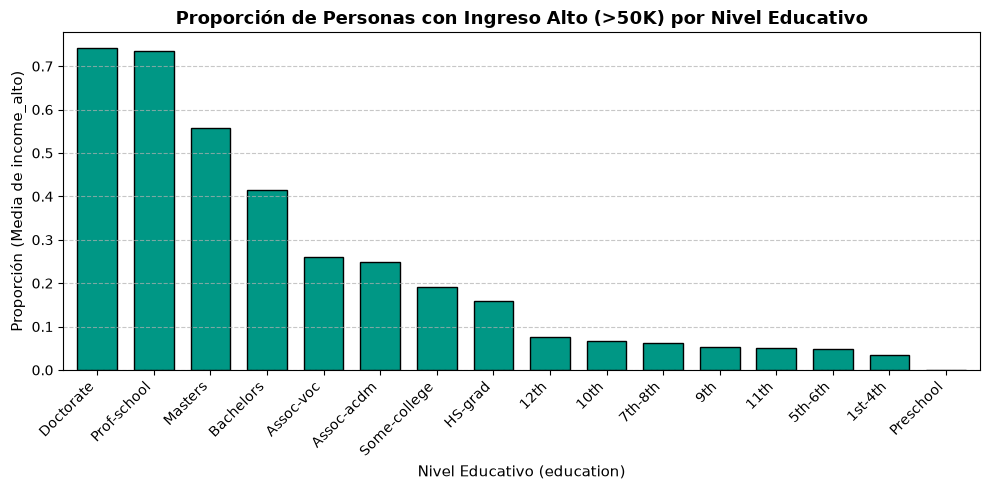

In [10]:
# 3. Crear columna binaria income_alto (1 si >50K, 0 si <=50K)
# Usamos .str.strip() para asegurar consistencia
df_adult["income_alto"] = (df_adult["income"].str.strip() == ">50K").astype(int)

# Proporción de ingreso alto por nivel de education
prop_educacion = df_adult.groupby("education")["income_alto"].mean().sort_values(ascending=False)
print("Proporción de ingreso alto (>50K) por nivel de Educación")
print(prop_educacion.round(4))

# Proporción de ingreso alto por sex
prop_sexo = df_adult.groupby("sex")["income_alto"].mean().sort_values(ascending=False)
print("\n--- Proporción de ingreso alto (>50K) por Sexo ---")
print(prop_sexo.round(4))

# Visualización: Proporción de ingreso alto por nivel educativo
plt.figure(figsize=(10, 5))
prop_educacion.plot(kind="bar", color="#009785", edgecolor="black", width=0.7)
plt.title("Proporción de Personas con Ingreso Alto (>50K) por Nivel Educativo", fontsize=13, weight="bold")
plt.xlabel("Nivel Educativo (education)", fontsize=11)
plt.ylabel("Proporción (Media de income_alto)", fontsize=11)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [11]:
# 4. Contar cuántos registros tienen exactamente 99999
conteo_99999 = (df_adult["capital_gain"] == 99999).sum()
porcentaje_99999 = (conteo_99999 / len(df_adult)) * 100

print(f"Registros con capital_gain == 99999: {conteo_99999} ({porcentaje_99999:.2f}% del total)")

Registros con capital_gain == 99999: 159 (0.49% del total)


## ¿Qué significa el valor 99999 en capital_gain?
No implica que todas esas personas hayan ganado exactamente $99,999 USD, sino que representa ganancias **iguales o superiores** a dicho umbral

In [12]:
# 5. Función de reporte de calidad de datos
def reporte_calidad_datos(df):
    """
    - dtype: Tipo de dato en pandas
    - n_unicos: Cantidad de valores únicos
    - %_faltantes: Porcentaje de valores nulos o faltantes
    - tipo_sugerido: Clasificación sugerida según cardinalidad y tipo
    """
    filas = []
    total_filas = len(df)
    
    for col in df.columns:
        dt = df[col].dtype
        unicos = df[col].nunique()
        nulos = df[col].isnull().sum()
        pct_faltantes = round((nulos / total_filas) * 100, 2)
        
        # Reglas para inferir el tipo sugerido
        if unicos == 2:
            tipo_sug = "Binaria"
        elif dt == "object" or dt.name == "category":
            tipo_sug = "Cualitativa Nominal"
        elif pd.api.types.is_integer_dtype(dt):
            tipo_sug = "Cuantitativa Discreta"
        elif pd.api.types.is_float_dtype(dt):
            tipo_sug = "Cuantitativa Continua"
        else:
            tipo_sug = "Otro"
            
        filas.append({
            "columna": col,
            "dtype": str(dt),
            "n_unicos": unicos,
            "%_faltantes": pct_faltantes,
            "tipo_sugerido": tipo_sug
        })
        
    return pd.DataFrame(filas).set_index("columna")

# Obtener y mostrar el reporte del DataFrame original
reporte = reporte_calidad_datos(df_adult)
print("REPORTE DE CALIDAD DE DATOS")
print(reporte)

REPORTE DE CALIDAD DE DATOS
                dtype  n_unicos  %_faltantes          tipo_sugerido
columna                                                            
age             int64        73         0.00  Cuantitativa Discreta
workclass         str         8         5.64                   Otro
fnlwgt          int64     21648         0.00  Cuantitativa Discreta
education         str        16         0.00                   Otro
education_num   int64        16         0.00  Cuantitativa Discreta
marital_status    str         7         0.00                   Otro
occupation        str        14         5.66                   Otro
relationship      str         6         0.00                   Otro
race              str         5         0.00                   Otro
sex               str         2         0.00                Binaria
capital_gain    int64       119         0.00  Cuantitativa Discreta
capital_loss    int64        92         0.00  Cuantitativa Discreta
hours_per_week  int6

## ¿Qué columnas tienen faltantes y en qué %Porcentaje? 

Al evaluar el archivo con na_values="?", se identifican datos faltantes únicamente en tres columnas cualitativas:

occupation: 1,843 registros faltantes -> 5.66% 

workclass: 1,836 registros faltantes -> 5.64% 

native_country: 583 registros faltantes -> 1.79% 

Todas las demás columnas (age, fnlwgt, education, capital_gain, etc.) tienen 0.00% de valores faltantes.

---
## Ejercicio 3: Datos faltantes (30 pts)

Usa el archvio `co2_owid.csv`: emisiones de CO₂ (millones de toneladas), CO₂ per cápita, población y PIB por país y año desde 1950 (formato largo: un renglón por país‑año).

**Faltantes**

1. (10 pts) Calcula conteo y % de faltantes por columna.
2. (10 pts) Filtra los renglones donde `iso_code` es faltante y revisa los valores de `country`. ¿Qué puedes concluir de este análisis?. Crea un nuevo dataframe llamado `paises` excluyéndo las observaciones donde `iso_code` es faltante.
3. (10 pts) En el dataframe `paises`, grafica el % de faltantes de `co2` y de `gdp` por `year`. 



In [13]:
# Ejercicio 3 - Faltantes
#Cargar el dataset usando la variable DATOS
ruta_co2 = os.path.join(DATOS, "co2_owid.csv")
df_co2 = pd.read_csv(ruta_co2)

# 1.- Conteo y porcentaje de faltantes por columna
conteo_faltantes = df_co2.isnull().sum()
pct_faltantes = (df_co2.isnull().mean() * 100).round(2)

tabla_faltantes = pd.DataFrame({
    "conteo_faltantes": conteo_faltantes,
    "porcentaje_faltantes (%)": pct_faltantes
}).sort_values(by="porcentaje_faltantes (%)", ascending=False)

print("CONTEO Y % DE FALTANTES POR COLUMNA")
print(tabla_faltantes)

CONTEO Y % DE FALTANTES POR COLUMNA
                conteo_faltantes  porcentaje_faltantes (%)
gdp                         7512                     39.57
iso_code                    2634                     13.87
co2_per_capita              2491                     13.12
population                  1809                      9.53
co2                         1437                      7.57
year                           0                      0.00
country                        0                      0.00


In [14]:
# 2.- Filtrar renglones donde iso_code es faltante y ver entidades de 'country'
df_sin_iso = df_co2[df_co2["iso_code"].isnull()]
entidades_sin_iso = df_sin_iso["country"].unique()

print(f"Total de registros sin iso_code: {len(df_sin_iso)}")
print(f"Total de entidades únicas sin iso_code: {len(entidades_sin_iso)}")
print("\nEjemplos de entidades sin iso_code:")
print(entidades_sin_iso)

# Crear nuevo DataFrame 'paises' excluyendo las observaciones donde iso_code es nulo
paises = df_co2[df_co2["iso_code"].notna()].copy()

print(f"\nDimensiones del dataset original: {df_co2.shape}")
print(f"Dimensiones del DataFrame 'paises': {paises.shape}")

Total de registros sin iso_code: 2634
Total de entidades únicas sin iso_code: 36

Ejemplos de entidades sin iso_code:
<ArrowStringArray>
[                                  'Africa',
                             'Africa (GCP)',
                                     'Asia',
                               'Asia (GCP)',
             'Asia (excl. China and India)',
                    'Central America (GCP)',
                                   'Europe',
                             'Europe (GCP)',
                     'Europe (excl. EU-27)',
                     'Europe (excl. EU-28)',
                      'European Union (27)',
                      'European Union (28)',
                    'High-income countries',
                   'International aviation',
                   'International shipping',
                                   'Kosovo',
                        'Kuwaiti Oil Fires',
                  'Kuwaiti Oil Fires (GCP)',
 'Least developed countries (Jones et al.)',
        

## ¿Qué puedes concluir de este análisis?

Naturaleza de los registros sin iso_code: Las observaciones donde iso_code es nulo no corresponden a países individuales, sino a:

Continentes y regiones geográficas: (p. ej., Africa, Asia, Europe, North America, South America, Oceania).

Agrupaciones socioeconómicas y geopolíticas: (p. ej., European Union (27), High-income countries, Low-income countries, OECD).

Importancia de filtrarlos: Excluir estas filas es un paso indispensable de limpieza para evitar la duplicidad de datos (doble conteo). Si se mantuvieran, al sumar o promediar emisiones globales se contaría dos veces cada emisión (una vez en el país individual y otra en su respectivo continente o bloque económico).

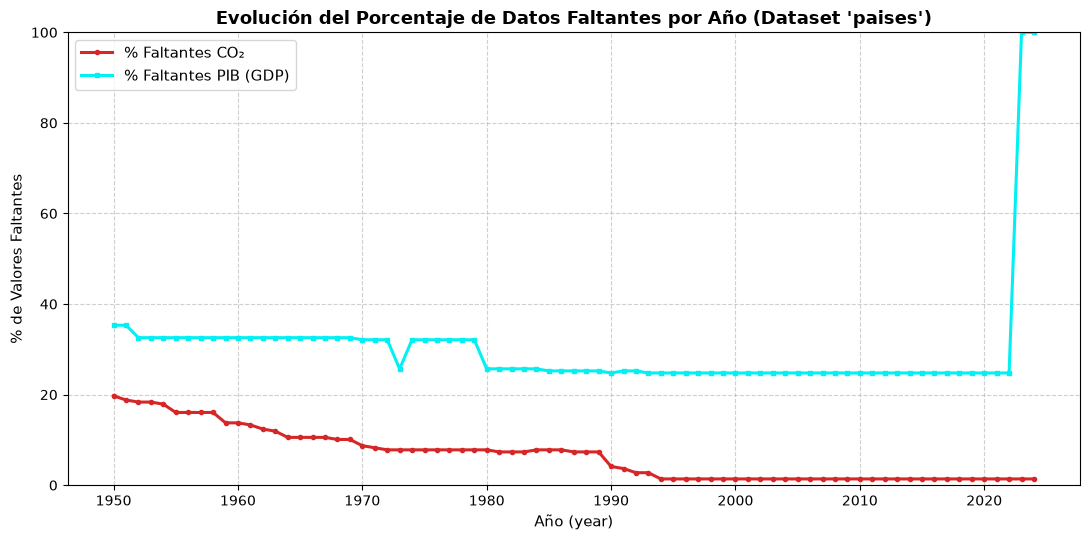

In [15]:
# 3. Calcular el % de faltantes de co2 y gdp agrupado por año
faltantes_por_anio = (
    paises.groupby("year")[["co2", "gdp"]]
    .apply(lambda col: col.isnull().mean() * 100)
)

# Graficar la evolución temporal del porcentaje de faltantes
plt.figure(figsize=(11, 5.5))
plt.plot(
    faltantes_por_anio.index,
    faltantes_por_anio["co2"],
    label="% Faltantes CO₂",
    color="#d62728",
    linewidth=2.2,
    marker="o",
    markersize=3
)
plt.plot(
    faltantes_por_anio.index,
    faltantes_por_anio["gdp"],
    label="% Faltantes PIB (GDP)",
    color="#00f0f4",
    linewidth=2.2,
    marker="s",
    markersize=3
)

plt.title("Evolución del Porcentaje de Datos Faltantes por Año (Dataset 'paises')", fontsize=13, weight="bold")
plt.xlabel("Año (year)", fontsize=11)
plt.ylabel("% de Valores Faltantes", fontsize=11)
plt.ylim(0, 100)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()